# Étude Exploratoire des Données (EDA)
**Projet :** Prédiction de l'Abandon Universitaire (Dataset xAPI-Edu-Data)
**Objectif :** Analyser les facteurs qui influencent la réussite ou l'échec des étudiants.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Chemin vers le fichier CSV
data_path = "../../data/raw/xAPI-Edu-Data.csv"
df = pd.read_csv(data_path)

print("Aperçu des 5 premières lignes :")
df.head()

Aperçu des 5 premières lignes :


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


## 1. Répartition de la Variable Cible (Class)
On regarde combien d'étudiants sont en :
* **L (Low)** : Risque élevé d'échec.
* **M (Medium)** : Risque moyen.
* **H (High)** : Réussite élevée.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14700\3486564074.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, order=['L', 'M', 'H'], palette='viridis')


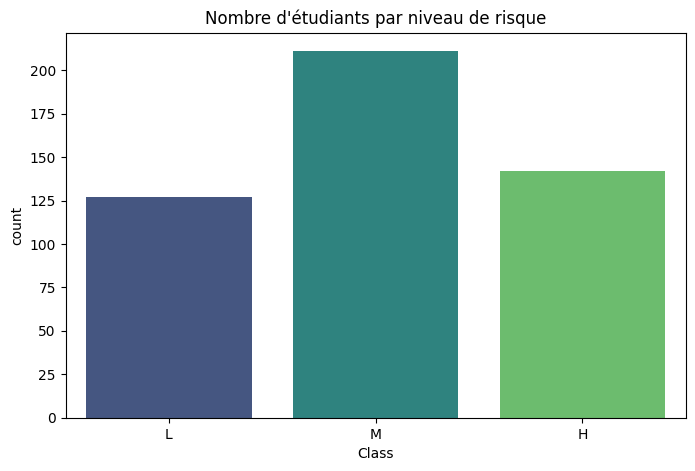

In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, order=['L', 'M', 'H'], palette='viridis')
plt.title('Nombre d\'étudiants par niveau de risque')
plt.show()

"Ce graphique présente la distribution des étudiants selon leur niveau de performance (L : Faible, M : Moyen, H : Élevé). On observe que la classe 'M' est la plus représentée, suivie de 'H' et 'L'. Bien que les classes ne soient pas parfaitement égales, la répartition est suffisamment équilibrée pour permettre à nos modèles de Machine Learning d'apprendre les caractéristiques de chaque groupe sans biais majeur."

## 2. Participation vs Réussite
Nous comparons les "Mains levées" et les "Ressources visitées" pour voir si cela influence la classe finale.

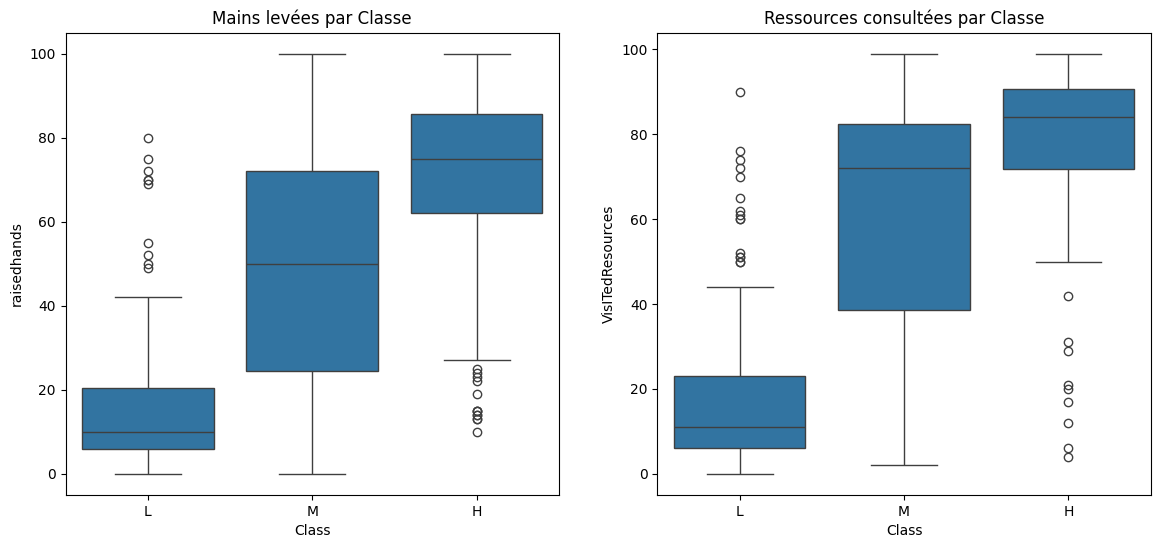

In [3]:
plt.figure(figsize=(14, 6))

# Sous-graphique 1 : Mains levées
plt.subplot(1, 2, 1)
sns.boxplot(x='Class', y='raisedhands', data=df, order=['L', 'M', 'H'])
plt.title('Mains levées par Classe')

# Sous-graphique 2 : Ressources consultées
plt.subplot(1, 2, 2)
sns.boxplot(x='Class', y='VisITedResources', data=df, order=['L', 'M', 'H'])
plt.title('Ressources consultées par Classe')

plt.show()

"Ces boîtes à moustaches (Boxplots) révèlent une corrélation directe et positive entre l'engagement comportemental et la réussite académique. Les étudiants de la classe 'H' (Réussite élevée) affichent des médianes de participation (mains levées) et de consultation des ressources nettement supérieures à ceux de la classe 'L'. Cela prouve que l'interactivité numérique est un indicateur précoce et fiable de la performance d'un étudiant."

## 3. Impact des Absences
On vérifie si les étudiants qui s'absentent souvent (plus de 7 jours) sont plus à risque.

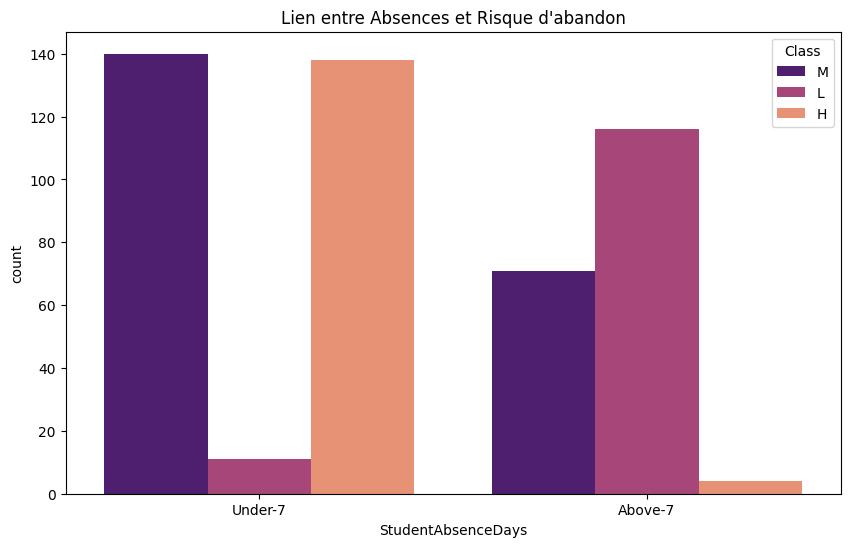

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(x='StudentAbsenceDays', hue='Class', data=df, palette='magma')
plt.title('Lien entre Absences et Risque d\'abandon')
plt.show()

"Ce graphique est le plus révélateur de notre étude. Il montre une cassure nette : l'immense majorité des étudiants ayant moins de 7 jours d'absence réussissent (Classes M et H), tandis que la quasi-totalité des étudiants cumulant plus de 7 jours d'absence se retrouvent en situation d'échec (Classe L). L'absentéisme apparaît donc comme le prédicteur numéro 1 du risque de décrochage scolaire dans ce dataset."

## Conclusion de l'analyse
L'exploration montre que les étudiants en classe **L (Low)** sont ceux qui participent le moins et qui s'absentent le plus. 
Ces variables seront donc cruciales pour notre modèle de Machine Learning.

# 🏁 Conclusion Générale - Projet Machine Learning

Ce projet a permis de développer une solution d'intelligence artificielle capable de prédire le risque d'abandon scolaire en se basant sur des données comportementales et académiques.

### 📊 Synthèse des Résultats Techniques
*   **Pipeline Modulaire :** La séparation du code en modules (Prétraitement, Entraînement, Évaluation) garantit la maintenabilité du projet.
*   **Benchmarking :** Nous avons comparé plusieurs algorithmes : Logistic Regression, Random Forest et XGBoost.
*   **Performance :** Le modèle **Random Forest** est le plus performant avec une **précision (Accuracy) de 86,46%**.
*   **F1-Score :** Avec un score de **0,87**, le modèle montre un excellent équilibre entre la détection des étudiants à risque et ceux en réussite.

### 🔍 Facteurs Déterminants Identifiés
L'analyse exploratoire et l'étude de l'importance des variables ont révélé que la réussite universitaire repose sur trois piliers :
1.  **L'Assiduité :** Le nombre d'absences est le signal le plus critique. Dépasser 7 jours d'absence multiplie drastiquement les risques d'échec.
2.  **L'Engagement Actif :** La participation en classe (mains levées) et la consultation des ressources numériques sont directement corrélées à une réussite élevée.
3.  **L'Implication :** La consultation des annonces et la participation aux forums complètent le profil de l'étudiant engagé.

### 💡 Impact et Valeur Ajoutée
Grâce à ce modèle, l'institution peut désormais :
*   **Identifier les signaux d'alerte** dès les premières semaines du semestre.
*   **Intervenir de manière ciblée** auprès des étudiants montrant un faible engagement ou un absentéisme croissant.
*   **Réduire le taux d'abandon global** en transformant les données en leviers d'accompagnement pédagogique.
  
  